# Task 1 — Data Merge
### Formative 2: Multimodal Data Preprocessing

**Goal:** merge `customer_transactions` and `customer_social_profiles` into a single dataset that can later train a model predicting the product a customer is likely to purchase, based on their social media behavior.

This notebook covers:
1. Exploratory Data Analysis (EDA) on both raw sources
2. Data cleaning (nulls, duplicates, outliers)
3. Join-key reconciliation and a justified merge strategy
4. Post-merge validation
5. Feature engineering on the merged dataset


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

# Course-provided datasets. Place both .xlsx files in this task1_data_merge/ folder
# and COMMIT them to the repo -- 'Datasets' is a required deliverable. The loader
# below checks the local folder first, then a data/ subfolder, so the notebook runs
# top-to-bottom from a fresh clone with no path edits.
from pathlib import Path
def _find(name):
    for cand in (Path(name), Path('data') / name, Path('/mnt/user-data/uploads') / name):
        if cand.exists():
            return cand
    raise FileNotFoundError(
        f'{name} not found. Put the course-provided {name} in this folder '
        f'(task1_data_merge/) before running this notebook.')
trans = pd.read_excel(_find('data/customer_transactions.xlsx'))
social = pd.read_excel(_find('data/customer_social_profiles.xlsx'))

print('customer_transactions:', trans.shape)
print('customer_social_profiles:', social.shape)


## 1. Exploratory Data Analysis

### 1.1 `customer_transactions` — structure & summary stats

In [ ]:
trans.info()


<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   customer_id_legacy  150 non-null    int64         
 1   transaction_id      150 non-null    int64         
 2   purchase_amount     150 non-null    int64         
 3   purchase_date       150 non-null    datetime64[us]
 4   product_category    150 non-null    str           
 5   customer_rating     140 non-null    float64       
dtypes: datetime64[us](1), float64(1), int64(3), str(1)
memory usage: 7.2 KB


In [ ]:
trans.describe(include='all')


,customer_id_legacy,transaction_id,purchase_amount,purchase_date,product_category,customer_rating
count,150.000000,150.000000,150.000000,150,150,140.00000
unique,NaN,NaN,NaN,NaN,5,NaN
top,NaN,NaN,NaN,NaN,Sports,NaN
freq,NaN,NaN,NaN,NaN,35,NaN
mean,148.760000,1075.500000,280.780000,2024-03-15 12:00:00,NaN,2.98500
min,100.000000,1001.000000,51.000000,2024-01-01 00:00:00,NaN,1.00000
25%,121.250000,1038.250000,179.000000,2024-02-07 06:00:00,NaN,1.95000
50%,150.500000,1075.500000,274.000000,2024-03-15 12:00:00,NaN,3.00000
75%,174.750000,1112.750000,388.500000,2024-04-21 18:00:00,NaN,4.00000
max,199.000000,1150.000000,495.000000,2024-05-29 00:00:00,NaN,5.00000


**Observations:**
- 150 transactions across 75 unique customers (`customer_id_legacy`) — customers can purchase more than once.
- `customer_rating` has 10 missing values (~6.7%) — everything else is complete.
- `transaction_id` has zero duplicates, so each row is a distinct transaction.
- 5 product categories: Sports, Electronics, Clothing, Groceries, Books.


### 1.2 `customer_transactions` — distributions, outliers, correlation

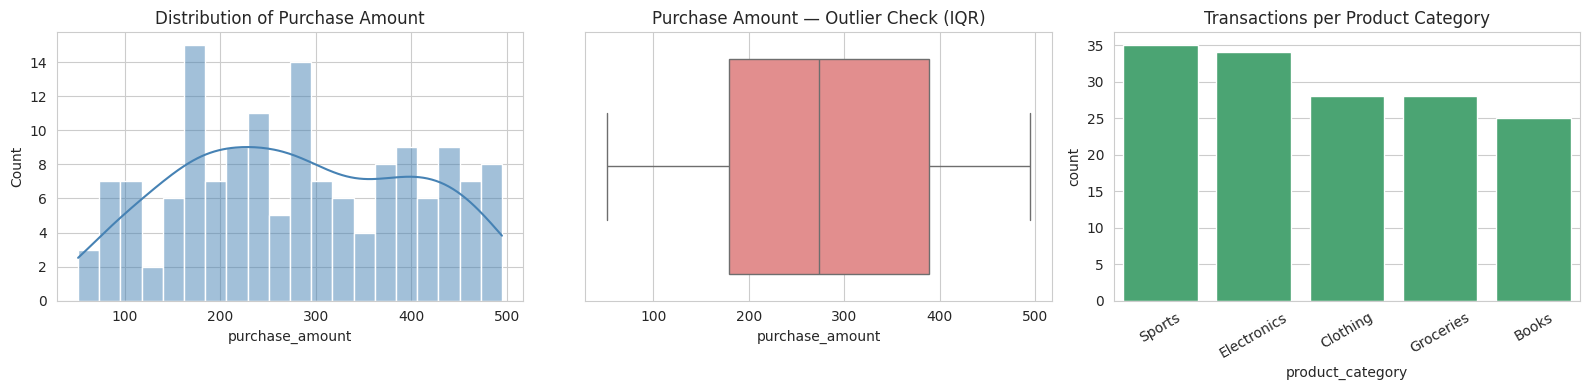

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(trans['purchase_amount'], bins=20, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Purchase Amount')

sns.boxplot(x=trans['purchase_amount'], ax=axes[1], color='lightcoral')
axes[1].set_title('Purchase Amount — Outlier Check (IQR)')

sns.countplot(data=trans, x='product_category', order=trans['product_category'].value_counts().index,
              ax=axes[2], color='mediumseagreen')
axes[2].set_title('Transactions per Product Category')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('trans_eda_1.png')
plt.show()


In [ ]:
q1, q3 = trans['purchase_amount'].quantile([0.25, 0.75])
iqr = q3 - q1
lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
outliers = trans[(trans['purchase_amount'] < lo) | (trans['purchase_amount'] > hi)]
print(f'IQR bounds: [{lo:.1f}, {hi:.1f}]  -> {len(outliers)} outliers detected')


IQR bounds: [-135.2, 702.8]  -> 0 outliers detected


**Observation:** `purchase_amount` is fairly uniformly spread \$51–\$495 with **no outliers** by the IQR rule — no extreme values to clip or investigate. `Electronics` and `Sports` are the most frequent categories in this sample.

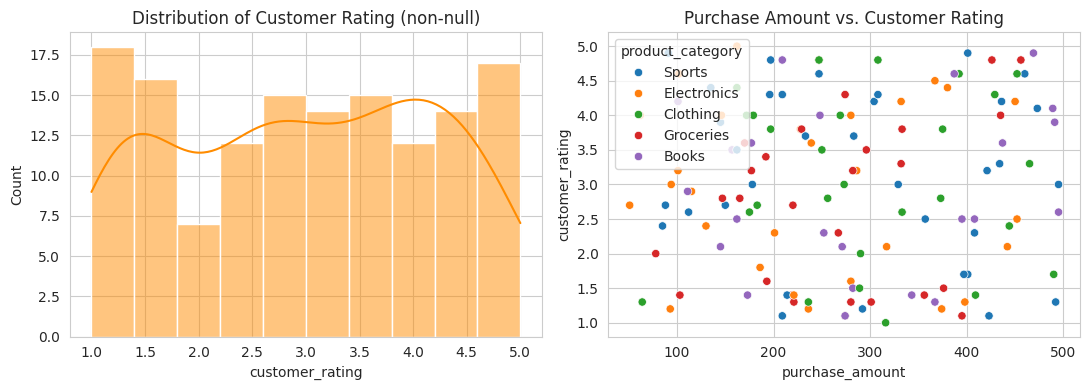

Correlation (purchase_amount, customer_rating): 0.031


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.histplot(trans['customer_rating'].dropna(), bins=10, kde=True, ax=axes[0], color='darkorange')
axes[0].set_title('Distribution of Customer Rating (non-null)')

sns.scatterplot(data=trans, x='purchase_amount', y='customer_rating', hue='product_category', ax=axes[1])
axes[1].set_title('Purchase Amount vs. Customer Rating')

plt.tight_layout()
plt.savefig('trans_eda_2.png')
plt.show()

print('Correlation (purchase_amount, customer_rating):',
      round(trans['purchase_amount'].corr(trans['customer_rating']), 3))


**Observation:** Correlation between `purchase_amount` and `customer_rating` is close to 0 — how much someone spends doesn't predict how they rated the purchase in this sample. No obvious category-based clustering in the scatter either.

### 1.3 `customer_social_profiles` — structure & summary stats

In [ ]:
social.info()


<class 'pandas.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id_new          155 non-null    str    
 1   social_media_platform    155 non-null    str    
 2   engagement_score         155 non-null    int64  
 3   purchase_interest_score  155 non-null    float64
 4   review_sentiment         155 non-null    str    
dtypes: float64(1), int64(1), str(3)
memory usage: 6.2 KB


In [ ]:
social.describe(include='all')


,customer_id_new,social_media_platform,engagement_score,purchase_interest_score,review_sentiment
count,155,155,155.000000,155.000000,155
unique,84,5,NaN,NaN,3
top,A155,Twitter,NaN,NaN,Positive
freq,7,38,NaN,NaN,63
mean,NaN,NaN,75.606452,3.152903,NaN
std,NaN,NaN,14.568021,1.142867,NaN
min,NaN,NaN,50.000000,1.000000,NaN
25%,NaN,NaN,63.500000,2.350000,NaN
50%,NaN,NaN,77.000000,3.200000,NaN
75%,NaN,NaN,87.500000,4.100000,NaN


**Observations:**
- 155 rows, 84 unique customers (`customer_id_new`, format `A###`) — most customers have **more than one row** (multiple platform interactions/reviews), so this is not one-row-per-customer.
- No missing values.
- 5 platforms (LinkedIn, Twitter, Facebook, TikTok, Instagram) and 3 sentiment classes (Positive/Neutral/Negative).


### 1.4 `customer_social_profiles` — distributions & correlation

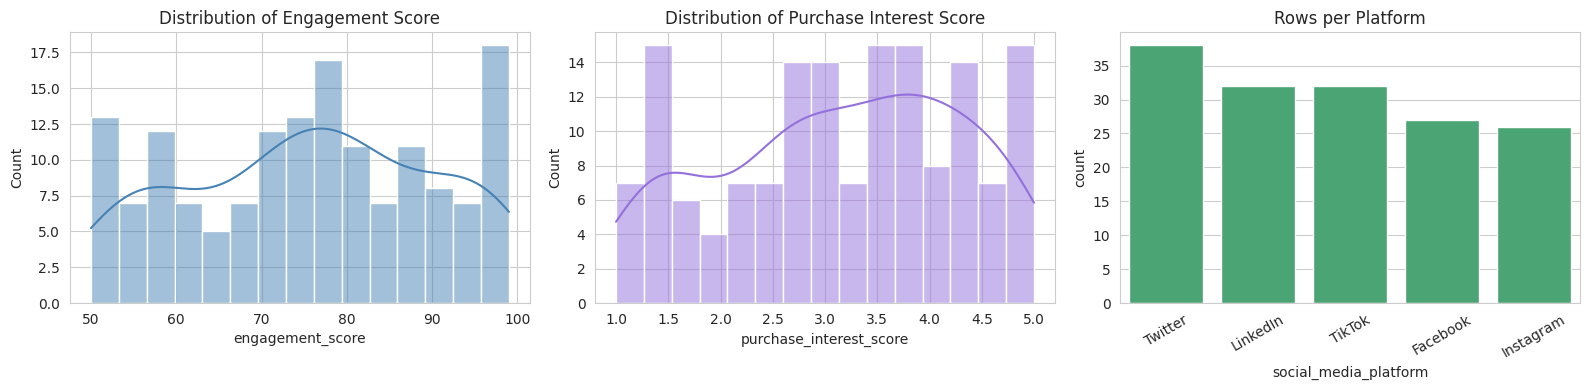

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(social['engagement_score'], bins=15, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Engagement Score')

sns.histplot(social['purchase_interest_score'], bins=15, kde=True, ax=axes[1], color='mediumpurple')
axes[1].set_title('Distribution of Purchase Interest Score')

sns.countplot(data=social, x='social_media_platform',
              order=social['social_media_platform'].value_counts().index, ax=axes[2], color='mediumseagreen')
axes[2].set_title('Rows per Platform')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('social_eda_1.png')
plt.show()


Correlation (engagement_score, purchase_interest_score): 0.088


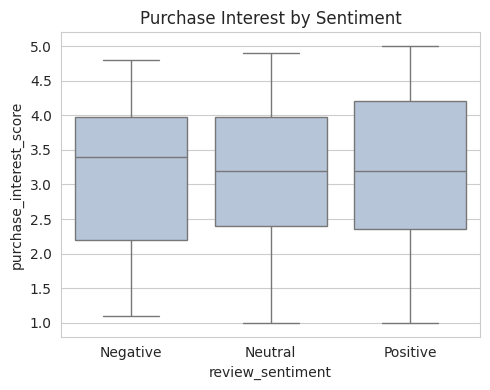

In [ ]:
print('Correlation (engagement_score, purchase_interest_score):',
      round(social['engagement_score'].corr(social['purchase_interest_score']), 3))

fig, ax = plt.subplots(figsize=(5, 4))
sns.boxplot(data=social, x='review_sentiment', y='purchase_interest_score',
            order=['Negative', 'Neutral', 'Positive'], ax=ax, color='lightsteelblue')
ax.set_title('Purchase Interest by Sentiment')
plt.tight_layout()
plt.savefig('social_eda_2.png')
plt.show()


**Observation:** engagement and purchase-interest scores are essentially uncorrelated, and purchase interest doesn't shift much with review sentiment in this sample — being more "engaged" on social doesn't by itself signal purchase intent, which is exactly why we need the *transaction* data to get a real purchase label.

## 2. Data Cleaning

**Transactions:**
- No duplicate rows, no duplicate `transaction_id`s.
- `customer_rating` missing for 10 rows → imputed with the **median rating within the same `product_category`** (rather than a single global median), since rating tendency plausibly differs by category.
- No outliers in `purchase_amount` by the IQR rule, so nothing to clip.

**Social profiles:**
- 5 fully duplicated rows → dropped (identical repeated records add no information).
- No missing values.


In [ ]:
trans['customer_rating'] = trans.groupby('product_category')['customer_rating'].transform(
    lambda x: x.fillna(x.median())
)
assert trans['customer_rating'].isnull().sum() == 0

print('Duplicate rows in social before cleaning:', social.duplicated().sum())
social = social.drop_duplicates().reset_index(drop=True)
print('Social shape after de-duplication:', social.shape)


Duplicate rows in social before cleaning: 5
Social shape after de-duplication: (150, 5)


## 3. Reconciling the Join Key

The two files identify customers differently:
- `customer_transactions.customer_id_legacy` — integer, e.g. `151`
- `customer_social_profiles.customer_id_new` — string, e.g. `"A178"`

Stripping the `"A"` prefix and casting to `int` recovers a common numeric customer ID present in both files (validated below — every ID matches the `A\d+` pattern, so the conversion is safe).


In [ ]:
assert social['customer_id_new'].str.match(r'^A\d+$').all()
social['customer_id'] = social['customer_id_new'].str.replace('A', '', regex=False).astype(int)
trans = trans.rename(columns={'customer_id_legacy': 'customer_id'})

trans_ids, social_ids = set(trans['customer_id']), set(social['customer_id'])
overlap = trans_ids & social_ids
print(f'Unique customers — transactions: {len(trans_ids)}, social: {len(social_ids)}, overlap: {len(overlap)}')
print(f'Transaction-only customers (no social data, excluded): {len(trans_ids - social_ids)}')
print(f'Social-only customers (no purchase history, excluded): {len(social_ids - trans_ids)}')


Unique customers — transactions: 75, social: 84, overlap: 61
Transaction-only customers (no social data, excluded): 14
Social-only customers (no purchase history, excluded): 23


### Why an inner join on `customer_id`

The target model predicts **what a customer will purchase based on their social behavior**. That needs both:
- a **label** → which only exists for customers with transactions, and
- **features** → which only exist for customers with social activity.

A customer missing either side can't be used for supervised training, so an **inner join** is the right choice here — a left join would leave feature-less rows with nothing to learn from, and would need heavy imputation to fill in social features that just don't exist for those customers.

### Handling the social side's granularity

`customer_social_profiles` has *multiple rows per customer* (repeated platform interactions), while `customer_transactions` has one row per transaction. Merging directly on `customer_id` without addressing this would **fan out** every transaction by however many social rows that customer has, corrupting the row-level meaning of the dataset. So social data is aggregated to **one row per customer** first, then merged into the transaction-level table (each transaction inherits its customer's aggregated social profile).


In [ ]:
sentiment_map = {'Positive': 1, 'Neutral': 0, 'Negative': -1}
social['sentiment_numeric'] = social['review_sentiment'].map(sentiment_map)

def mode_or_first(s):
    m = s.mode()
    return m.iloc[0] if len(m) else s.iloc[0]

social_agg = social.groupby('customer_id').agg(
    avg_engagement_score=('engagement_score', 'mean'),
    avg_purchase_interest_score=('purchase_interest_score', 'mean'),
    avg_sentiment_score=('sentiment_numeric', 'mean'),
    dominant_sentiment=('review_sentiment', mode_or_first),
    dominant_platform=('social_media_platform', mode_or_first),
    platform_diversity=('social_media_platform', 'nunique'),
    num_social_interactions=('social_media_platform', 'count'),
).reset_index()

print('Aggregated social profile shape (should be one row per unique customer):', social_agg.shape)
social_agg.head()


Aggregated social profile shape (should be one row per unique customer): (84, 8)


,customer_id,avg_engagement_score,avg_purchase_interest_score,avg_sentiment_score,dominant_sentiment,dominant_platform,platform_diversity,num_social_interactions
0,100,77.000000,4.400000,-0.500000,Negative,Instagram,2,2
1,101,68.000000,1.000000,0.000000,Neutral,Twitter,1,1
2,102,51.000000,4.800000,0.000000,Neutral,LinkedIn,1,1
3,103,64.333333,2.866667,0.333333,Positive,Instagram,2,3
4,104,83.000000,2.933333,-0.666667,Negative,Twitter,2,3


In [ ]:
merged = trans.merge(social_agg, on='customer_id', how='inner')
print('Merged dataset shape:', merged.shape)
merged.head()


Merged dataset shape: (117, 13)


,customer_id,transaction_id,purchase_amount,purchase_date,product_category,customer_rating,avg_engagement_score,avg_purchase_interest_score,avg_sentiment_score,dominant_sentiment,dominant_platform,platform_diversity,num_social_interactions
0,151,1001,408,2024-01-01,Sports,2.3,71.666667,2.166667,-0.333333,Neutral,Twitter,2,3
1,192,1002,332,2024-01-02,Electronics,4.2,60.000000,4.300000,1.000000,Positive,Instagram,1,1
2,114,1003,442,2024-01-03,Electronics,2.1,87.000000,4.800000,-1.000000,Negative,Facebook,1,1
3,160,1005,64,2024-01-05,Clothing,1.3,72.666667,2.500000,0.333333,Neutral,Instagram,3,3
4,120,1006,395,2024-01-06,Groceries,1.1,77.000000,2.666667,1.000000,Positive,Instagram,2,3


## 4. Post-Merge Validation

In [ ]:
# 1) Row count sanity check: merged rows should equal transactions belonging to overlapping customers
expected_rows = trans[trans['customer_id'].isin(overlap)].shape[0]
print('Expected rows:', expected_rows, '| Actual merged rows:', merged.shape[0])
assert merged.shape[0] == expected_rows, 'Unexpected fan-out or row loss in the merge!'
print('PASS — no fan-out, no unexpected row loss.')

# 2) Null check
print('\nTotal null cells post-merge:', merged.isnull().sum().sum())

# 3) Spot-check one customer's aggregated value against a manual recomputation
sample_id = sorted(overlap)[0]
manual_mean = social.loc[social['customer_id'] == sample_id, 'engagement_score'].mean()
merged_val = merged.loc[merged['customer_id'] == sample_id, 'avg_engagement_score'].iloc[0]
print(f'\nSpot check — customer {sample_id}: manual mean={manual_mean:.2f}, merged value={merged_val:.2f}',
      '-> MATCH' if abs(manual_mean - merged_val) < 1e-9 else '-> MISMATCH')


Expected rows: 117 | Actual merged rows: 117
PASS — no fan-out, no unexpected row loss.

Total null cells post-merge: 0

Spot check — customer 100: manual mean=77.00, merged value=77.00 -> MATCH


All checks pass: the inner join produced exactly the expected number of rows (each transaction kept exactly once, only for customers present in both sources), there are no nulls introduced by the merge, and a manual spot-check confirms the aggregation math is correct.

## 5. Feature Engineering on the Merged Dataset

In [ ]:
merged['purchase_month'] = merged['purchase_date'].dt.month
merged['is_high_value_purchase'] = (merged['purchase_amount'] > merged['purchase_amount'].median()).astype(int)
merged['product_category_code'] = merged['product_category'].astype('category').cat.codes
merged['dominant_platform_code'] = merged['dominant_platform'].astype('category').cat.codes

merged.info()


<class 'pandas.DataFrame'>
RangeIndex: 117 entries, 0 to 116
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   customer_id                  117 non-null    int64         
 1   transaction_id               117 non-null    int64         
 2   purchase_amount              117 non-null    int64         
 3   purchase_date                117 non-null    datetime64[us]
 4   product_category             117 non-null    str           
 5   customer_rating              117 non-null    float64       
 6   avg_engagement_score         117 non-null    float64       
 7   avg_purchase_interest_score  117 non-null    float64       
 8   avg_sentiment_score          117 non-null    float64       
 9   dominant_sentiment           117 non-null    str           
 10  dominant_platform            117 non-null    str           
 11  platform_diversity           117 non-null    int64      

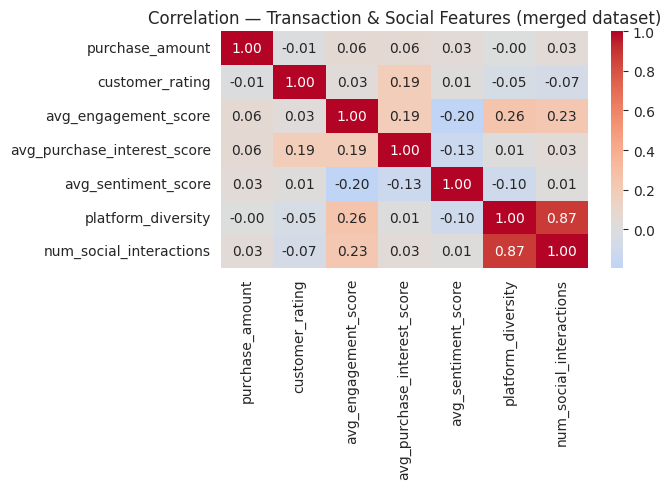

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
corr_cols = ['purchase_amount', 'customer_rating', 'avg_engagement_score',
             'avg_purchase_interest_score', 'avg_sentiment_score', 'platform_diversity',
             'num_social_interactions']
sns.heatmap(merged[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation — Transaction & Social Features (merged dataset)')
plt.tight_layout()
plt.savefig('merged_corr.png')
plt.show()


**Observation:** none of the social features correlate strongly with `purchase_amount` on their own — which is expected and realistic. This is exactly why Task 4 will use a model (not a single correlation) to combine `product_category`, `dominant_platform`, `avg_sentiment_score`, etc. into a joint prediction of the purchased product category.

## 6. Save Merged Dataset

This is the dataset that feeds the Product Recommendation model in Task 4, once the image/audio features from Tasks 2–3 are added as authentication-gate inputs.


In [ ]:
merged.to_csv('merged_customer_dataset.csv', index=False)
print('Saved merged_customer_dataset.csv —', merged.shape)
merged.head()


Saved merged_customer_dataset.csv — (117, 17)


,customer_id,transaction_id,purchase_amount,purchase_date,product_category,customer_rating,avg_engagement_score,avg_purchase_interest_score,avg_sentiment_score,dominant_sentiment,dominant_platform,platform_diversity,num_social_interactions,purchase_month,is_high_value_purchase,product_category_code,dominant_platform_code
0,151,1001,408,2024-01-01,Sports,2.3,71.666667,2.166667,-0.333333,Neutral,Twitter,2,3,1,1,4,4
1,192,1002,332,2024-01-02,Electronics,4.2,60.000000,4.300000,1.000000,Positive,Instagram,1,1,1,1,2,1
2,114,1003,442,2024-01-03,Electronics,2.1,87.000000,4.800000,-1.000000,Negative,Facebook,1,1,1,1,2,0
3,160,1005,64,2024-01-05,Clothing,1.3,72.666667,2.500000,0.333333,Neutral,Instagram,3,3,1,0,1,1
4,120,1006,395,2024-01-06,Groceries,1.1,77.000000,2.666667,1.000000,Positive,Instagram,2,3,1,1,3,1
